# Library Imports

In [1]:
import pandas as pd
import numpy as np

# used to download .json file from server
import requests

# used for progress bar during downloads
from tqdm.notebook import tqdm

# used for environment variable
# used for checking files are present
import os

# used to download ACS using census API
from census import Census

# used for ???
from typing import List, Dict

# used for creating cartesian products of variables
import itertools

#used for ???
from collections import defaultdict

# used for plots
import matplotlib.pyplot as plt

# Utility Functions

In [2]:
# TODO: add documentation and outline of function uses

In [3]:
# You'll need to get your own API key from the Census Bureau
# https://api.census.gov/data/key_signup.html

CENSUS_API_KEY = os.environ.get("CENSUS_API_KEY")
c1 = Census(CENSUS_API_KEY)

def get_acs_variable(year: int, variable_id: str):
    try:
        rows: List[Dict] = c1.acs5.get(variable_id, {"for": "county:*", "in": "state:*"}, year=year)

        df = pd.DataFrame(rows)
        # Standardize columns
        df["GEOID"] = df["state"] + df["county"]
        df["year"] = year
        return df
    except Exception as exce:
        print(f"An error occurred: {exce}")
        return None

def download_variables(var_list, year_list):
    # create every var year combination
    var_year_combo = list(itertools.product(var_list,year_list))

    # iterate through the combos creating a dictionary of vars
    # appending the returned df for each var
    dfs = defaultdict(list)
    for my_var,year in tqdm(var_year_combo, desc="Downloading variable tables"):
        dfs[my_var].append(get_acs_variable(year,my_var))

    # concat all the years into one df
    # set the index for the concatened dfs
    dfs_temp_list = []
    for key in dfs.keys():
        dfs_temp_list.append(pd.concat(dfs[key]).set_index(["GEOID","year"]))

    # join the different variables into one dataframe
    base_df = dfs_temp_list[0]
    my_data = base_df.join( [ df.drop(columns=['state','county']) for df in dfs_temp_list[1:] ]).reset_index()
    my_data = my_data.rename(columns={'year':'Year','state':'State','county':'County'})

    # reordering columns
    col_names = my_data.columns.to_list()
    temp = col_names[4]
    col_names[4] = col_names[2]
    col_names[2] = col_names[3]
    col_names[3] = temp
    my_data = my_data[ col_names ]

    return my_data

def download_necessary(FILE_LIST):
    confirm_needed = True
    confirm_override = None

    # Check if data already saved locally
    for filename in FILE_LIST:
        if not os.path.exists(filename):
            confirm_needed = False

    # If data is local ask for confirmation to download
    if confirm_needed:
        print("We are about to download substantial data from a server.\nThe data already appears to be present on the local disk.\n")
        confirm_override = input("Type `Override` to continue. Any other input will cancel download: ")

    # return true if files aren't local or override given
    if confirm_override == "Override" or not confirm_needed:
        return True
    else:
        print("Avoiding download. . . Using local data")
        return False

def find_all_missing_years(df: pd.DataFrame, variable_list: list) -> dict:
    """
    Finds all missing years for a list of variables in a single, vectorized operation.

    Args:
        df: The combined DataFrame containing a 'year' and 'Variable' column.
        variable_list: A list of variable names to check.

    Returns:
        A dictionary where keys are variable names and values are sorted lists
        of years where the variable is missing.
    """
    # 1. Get all unique years from the data
    all_the_years = df['Year'].unique()

    # 2. Create the "Expected" DataFrame: a complete grid of every variable for every year.
    #    This represents every data point that *should* exist.
    expected_combinations = list(itertools.product(all_the_years, variable_list))
    expected_df = pd.DataFrame(expected_combinations, columns=['Year', 'Variable'])

    # 3. Get the "Actual" DataFrame: the unique (year, Variable) pairs that *do* exist
    #    in data, but only for the variables we care about.
    my_mask = df['Variable'].isin(variable_list)
    actual_df = df[my_mask][['Year', 'Variable']].drop_duplicates()

    # 4. Find the missing data using a left merge with an indicator.
    #    This joins the 'expected' grid with the 'actual' data.
    #    Anything that exists only in the 'expected' grid is a missing data point.
    #    indicator=True adds a column that indicates whether the row was in the left, or
    #    both dataframes
    merged_df = expected_df.merge(actual_df, on=['Year', 'Variable'], how='left', indicator=True)

    # mask from the indicator column
    # if the data was from left only (the expected data)
    # than it is missing from the actual
    my_mask = merged_df['_merge'] == 'left_only'
    missing_df = merged_df[my_mask]
    # 5. Format the output to be a dictionary
    if missing_df.empty:
        return {}

    # groupby Variable name
    # focus in on the year column
    # get a list of years for each variable name
    # sort by variable name
    # turn it all into a dictionary
    missing_dict = missing_df.groupby('Variable')['Year'].apply(list).sort_index().to_dict()

    return missing_dict

# Initial Downloads Attempted


According to the BU project, we are looking for the variables listed in the table below. However, when initially downloading  these variables from the API, there were errors stating some of the variables were missing.

Therefore I will download the ACS metadata and analyze the variable and corresponding concepts.

## BU Documented Variables

|Variable | Label |
|---------|-------|
| B01003_001E | Total population of the local area |
|B25031_004E|Median gross rent for a 2-bedroom apartment.|
|B19013_001E|Median household income in the past 12 months.|
|B17001_001E|Poverty rate, indicating the percentage of individuals living below the poverty line.|
|B25004_001E|Percentage of rental properties that are vacant.|
|B25008_001E|Percentage of households that are renter-occupied.|
|B25106_006E, B25106_010E, B25106_014E, B25106_018E|Percentage of renter households paying more than 30% of their income toward rent.|
|B23001_001E|Unemployment rate, showing the percentage of the labor force that is unemployed.|

# Fetch Variable Metadata
Fetch the metadata and save it as a csv file for further investigation.

In [4]:
# Set the survey you are interested in
SURVEY = 'acs5'

METADATA_FILE = 'metadata.csv'
RAW_METADATA_FILE = 'raw_metadata.csv'

def download_metadata():
    metadata_dfs = []
    for my_year in tqdm(range(2009,2024), desc="Downloading Lot's of Metadata"):
        # Construct the URL for the variables endpoint
        url = f"https://api.census.gov/data/{my_year}/acs/{SURVEY}/variables.json"

        # Make the request to the API
        response = requests.get(url)

        # Check if the request was successful
        if response.status_code == 200:
            # Get the JSON data from the response
            variables_data = response.json()

            # The data is a dictionary where keys are variable IDs.
            # We can convert this directly into a pandas DataFrame.
            # The 'variables' key holds the main dictionary.
            df_vars = pd.DataFrame.from_dict(variables_data['variables'], orient='index')
            df_vars = df_vars.reset_index(names="Variable")
            df_vars = df_vars.rename(columns={"label":"Label","concept":"Concept"})
            df_vars['Year'] = my_year

            metadata_dfs.append(df_vars)

        else:
            print(f"Failed to fetch data. Status code: {response.status_code}")

    return metadata_dfs

def combine_save_metadata(metadata_dfs):
    raw_metadata = pd.concat(metadata_dfs)
    raw_metadata.to_csv(RAW_METADATA_FILE, index=False)

    columns_to_keep = ["Variable", "Label", "Concept", "Year"]
    my_metadata = raw_metadata[columns_to_keep]
    my_metadata.to_csv(METADATA_FILE, index=False)

    print("Saved raw_metadata and metadata to disk!")
    return my_metadata

file_list = [METADATA_FILE, RAW_METADATA_FILE]
if download_necessary(file_list):
    metadata_dfs = download_metadata()
    metadata = combine_save_metadata(metadata_dfs)
else:
    print("Reading data from file. . .)")
    metadata = pd.read_csv(METADATA_FILE)


Saved raw_metadata and metadata to disk!


## Checking Which Variables Are Missing

Finding the missing years for each variable. Using a fully vectorized approach.

In [5]:

variables_of_concern = [ "B01003_001E", "B25031_004E", "B19013_001E", "B17001_001E",
                        "B25004_001E", "B25008_001E", "B23001_001E", "B25106_006E",
                        "B25106_010E", "B25106_014E", "B25106_018E" ]

missing_years = find_all_missing_years(metadata,variables_of_concern)

# print out the missing years for each variable
for var in missing_years.keys():
    print(f"Variable: {var} missing in years: {missing_years[var]}")

Variable: B25031_004E missing in years: [2009, 2010, 2011, 2012, 2013, 2014]
Variable: B25106_006E missing in years: [2009]
Variable: B25106_010E missing in years: [2009]
Variable: B25106_014E missing in years: [2009]
Variable: B25106_018E missing in years: [2009]


## Missing Variable Summary
* Missing in 2009 thru 2014
    * B25031_004E
* Missing in 2009
    * B25106_006E
    * B25106_010E
    * B25106_014E
    * B25106_018E

# `Total Population`

## Checking Validity of Variable

In [6]:
# looking at metadata for this variable for
# the first year it's present
variable_mask = metadata['Variable'] == 'B01003_001E'
metadata[variable_mask].iloc[0]

Variable         B01003_001E
Label        Estimate!!Total
Concept     TOTAL POPULATION
Year                    2009
Name: 2108, dtype: object

In [7]:
# checking if any other variables share this concept
concept_mask = metadata['Concept'] == "TOTAL POPULATION"
metadata[concept_mask]

,Variable,Label,Concept,Year
2108,B01003_001E,Estimate!!Total,TOTAL POPULATION,2009
2233,B01003_001E,Estimate!!Total,TOTAL POPULATION,2010
2238,B01003_001E,Estimate!!Total,TOTAL POPULATION,2011
2338,B01003_001E,Estimate!!Total,TOTAL POPULATION,2012
2317,B01003_001E,Estimate!!Total,TOTAL POPULATION,2013
2256,B01003_001E,Estimate!!Total,TOTAL POPULATION,2014
2329,B01003_001E,Estimate!!Total,TOTAL POPULATION,2015
2328,B01003_001E,Estimate!!Total,TOTAL POPULATION,2016
1380,B01003_001E,Estimate!!Total,TOTAL POPULATION,2017
1433,B01003_001E,Estimate!!Total,TOTAL POPULATION,2018


## Summary of `Total Population`

This variable is located in all years. The concept matches the intended variable. This can be downloaded as is.
* Final Variable to Download:
    * B01003_001E

## Downloading Variable B01003_001E - TotalPopulation

In [8]:
TOTAL_POPULATION = "Total_Population_01.csv"

target_variables = ["B01003_001E"]
target_years = list(range(2009,2024))

if download_necessary([TOTAL_POPULATION]):
    total_population_df = download_variables(target_variables,target_years)
    total_population_df.to_csv(TOTAL_POPULATION, index=False)
else:
    base_dict = {
        'GEOID' : str,
        'Year' : int,
        'State' : str,
        'County' : str,
    }
    data_types = base_dict.copy()
    data_types['TotalPopulation'] = float

    total_population_df = pd.read_csv(TOTAL_POPULATION,dtype=data_types)


# `Median Rent`

## Checking Validity of Variable

### Looking at Variable Concept

In [9]:
var_mask = metadata["Variable"] == 'B25031_004E'
metadata[var_mask].iloc[0]

Variable                                       B25031_004E
Label       Estimate!!Median gross rent!!Total!!2 bedrooms
Concept                      MEDIAN GROSS RENT BY BEDROOMS
Year                                                  2015
Name: 2616, dtype: object

### Checking Variable Presence in All Years

In [10]:
years_missing = find_all_missing_years(metadata,['B25031_004E'])
f"Variable B25031_004E: Missing from years: {years_missing['B25031_004E']}"

'Variable B25031_004E: Missing from years: [2009, 2010, 2011, 2012, 2013, 2014]'

### Checking Possible Workaround For Missing Years

In [11]:
# checking which variables contain the bedrooms by gross rent concept
concept_mask = metadata["Concept"].str.contains("BEDROOMS BY GROSS RENT", na=False)
metadata[concept_mask]

,Variable,Label,Concept,Year
850,B25068_023E,Estimate!!Total!!2 bedrooms!!With cash rent!!$...,BEDROOMS BY GROSS RENT,2009
855,B25068_022E,Estimate!!Total!!2 bedrooms!!With cash rent!!L...,BEDROOMS BY GROSS RENT,2009
860,B25068_025E,Estimate!!Total!!2 bedrooms!!With cash rent!!$...,BEDROOMS BY GROSS RENT,2009
867,B25068_024E,Estimate!!Total!!2 bedrooms!!With cash rent!!$...,BEDROOMS BY GROSS RENT,2009
873,B25068_027E,Estimate!!Total!!2 bedrooms!!With cash rent!!$...,BEDROOMS BY GROSS RENT,2009
...,...,...,...,...
16605,B25068_012E,Estimate!!Total:!!1 bedroom:!!With cash rent:,BEDROOMS BY GROSS RENT,2021
16607,B25068_015E,Estimate!!Total:!!1 bedroom:!!With cash rent:!...,BEDROOMS BY GROSS RENT,2021
16616,B25068_014E,Estimate!!Total:!!1 bedroom:!!With cash rent:!...,BEDROOMS BY GROSS RENT,2021
16622,B25068_017E,Estimate!!Total:!!1 bedroom:!!With cash rent:!...,BEDROOMS BY GROSS RENT,2021


### Defining Workaround

Variable B25031-004E is the median gross rent of a two bedroom apartment. The counts of the number of two bedroom apartments by rent-range are variables B25068_022E through B25028E. Using these groupings we can estimate the median of a two bedroom apartment using linear interpolation.

## Downloading Variables B25068_022E through B25068_027E

In [12]:
# Variables of interest are B25068_022E to B25068_027E
vars_of_interest = [ f"B25068_0{num}E" for num in range(22,28) ]
# from year 2009 through 2024
years_of_interest = list(range(2009,2024))

RENT_BY_BEDROOMS_FILE = "Raw_Median_Rent_of_2_Bedrooms.csv"
if download_necessary([RENT_BY_BEDROOMS_FILE]):
    B25068 = download_variables(vars_of_interest, years_of_interest)
    B25068.to_csv(RENT_BY_BEDROOMS_FILE,index=False)

else:
    data_types = base_dict.copy()
    data_types['MedianRentOf2Bedrooms'] = float
    B25068 = pd.read_csv(RENT_BY_BEDROOMS_FILE, dtype=data_types)


## Forming Variable `MedianRentOf2Bedrooms`


### The Approach

#### Estimating the Median from Grouped Counts

You can estimate the median by using the formula for calculating the median from grouped data. This statistical method can be applied in situations where you have counts within specific ranges.

The process involves four main steps:
1.  Create a frequency table that includes the cumulative frequency.
2.  Find the position of the median value in the dataset.
3.  Identify which group contains the median.
4.  Use the formula to interpolate the median's exact position within that group.

#### The Formula

The standard formula to estimate the median from grouped data is:

$$Median = L + \frac{\frac{n}{2} - F}{f} \times w$$

Where:
* **$L$** = The **l**ower boundary of the group containing the median.
* **$n$** = The total cumulative count of all data (`sum of all frequencies`).
* **$F$** = The cumulative **f**requency of the groups *before* the median group.
* **$f$** = The **f**requency (the count) of the median group itself.
* **$w$** = The **w**idth of the median group interval.

***



### Finding the Intervals for the Groups

We need to extract the dollar amounts from the labels for each year

In [13]:
variable_names = [ f"B25068_0{num}E" for num in range(22,28) ]

var_mask = metadata["Variable"].isin(variable_names)
ranges_df = metadata[var_mask].copy()

# use pandas to match the regex '\$(\S+)'
# this expression matches the none white characters
# after a dollar sign. Stopping at the first whitespace.
# Findall returns a list of all the matches within the string
ranges_df["nums"] = ranges_df["Label"].str.findall(r'\$(\S+)')

# get the first match from the nums column saved above
# replace the $ and , with nothing to remove those characters
# the first match is the lowest numbers save in minimum column
ranges_df["minimum"] = pd.to_numeric(ranges_df["nums"].str.get(0).replace(r'[\$,]', '',regex=True))

# get the second match from the nums column saved above
# again, replace the $ and , with nothing to remove those characters
# the second match is the highest number save in maximum column
ranges_df["maximum"] = pd.to_numeric(ranges_df["nums"].str.get(1).replace(r'[\$,]', '',regex=True))

# two labels will have only one match the lowest range and the highest range
# the lowest range will contain the verbiage Less than (some number)
# the highest range will contain the verbiage more than (some number)
# the rows with nan's had only one match
# find out if it is the Less or more label
nan_mask = ranges_df["maximum"].isna()
less_mask= ranges_df["Label"].str.contains("Less")
more_mask = ranges_df["Label"].str.contains("more")

# for ranges with the less verbiage the only match is the highest or maximum of that range
# the lowest of the range will be zero
ranges_df.loc[nan_mask&less_mask,"maximum"] = ranges_df.loc[nan_mask&less_mask,"minimum"] - 1
ranges_df.loc[nan_mask&less_mask, "minimum"] = 0

# for ranges with the more verbaige the only match is the lowest or minimum of that range
# the highest of the range will be some undetermined number (we set it to a large value of 100,000 as a place holder)
ranges_df.loc[nan_mask&more_mask,"maximum"] = np.nan
# TODO: test the code with nan for maximum

year_mask = ranges_df["Year"] == 2023
num_intervals = ranges_df[["Variable", "Year", "minimum", "maximum"]]
num_intervals

,Variable,Year,minimum,maximum
850,B25068_023E,2009,200,299.0
855,B25068_022E,2009,0,199.0
860,B25068_025E,2009,500,749.0
867,B25068_024E,2009,300,499.0
873,B25068_027E,2009,1000,NaN
...,...,...,...,...
14049,B25068_022E,2023,0,299.0
14056,B25068_025E,2023,750,999.0
14061,B25068_024E,2023,500,749.0
14066,B25068_027E,2023,1500,NaN


$$Median = L + \frac{\frac{n}{2} - F}{f} \times w$$

* L (the lower boundary of the median group)
* n (the total count)
* F (the cumulative count of all groups before the median group)
* f (the count in the median group)
* w (the width of the interval

### Estimating the Median by Linear Interpolation

#### Find Cumulative Frequency Values

In [14]:
temp_df = B25068.copy()

variable_names = [ f"B25068_0{num}E" for num in range(22,28) ]
cf_names = [ f"Cumulative_Frequency_B25068_0{num}E" for num in range(22,28) ]

# the first count is the first CF value
last_cf_val = [0] * len(temp_df)

# loop through the counts
for (cf_val,var,i) in zip(cf_names, variable_names, range(0,len(variable_names))):
    # add current count to last CF count
    current_cf_val = temp_df[var] + last_cf_val
    # add the current cf val column to dataframe
    temp_df[cf_val] = current_cf_val
    # update the last CF count to the current CF val
    last_cf_val = current_cf_val


#### Find the DataPoint that Corresponds to the median value

In [15]:

# using the total count, divide by two to find
# the point the median lies on
temp_df['median_point'] = last_cf_val / 2

#### Find the Group the Median Value falls in

In [16]:

# set up conditions and choices for np.select.
# The conditions are the median point < the cumulative frequency, for each cumulative frequency.
# The choices corresponding to each condition are the column count name for each cf val
# np.select finds the first true condition (the first time the median point is less than
# the cumulative frequency). That is the group the median belongs to. Save that column name
# as median group.
conditions = [temp_df['median_point'] < temp_df[cf_val] for cf_val in cf_names ]
choices = [variable_name for variable_name in variable_names]
temp_df['median_group'] = np.select(conditions, choices, default=np.nan)

#### Handle Edge Case of Median Value Falling in the Group with no Upper Bound

In [17]:

# linear interpolation won't work when the median falls in the top bracket with no
# upper bound.
# TODO: find an estimate method, or leave as nans
mid_mask = temp_df['median_group'] == "B25068_027E"


#### Find the Lower and Upper Bounds of the Group the Median Belongs to, the width of that group, and total Frequency count of row

In [18]:

# match the corresponding intervals of the group the median belongs to
# rename the min and max intervals to lower and upper to indicate the
# lower and upper bounds of the median group
temp_df = pd.merge(left=temp_df, right=num_intervals.rename(columns={"Variable":"median_group"}), how='left', on=['median_group','Year'])
temp_df = temp_df.rename(columns={"minimum":"Lower","maximum":"Upper"})
# find the width of the median group
temp_df["width"] = temp_df["Upper"] - temp_df["Lower"]
# find the total count of all points (the last cf val)
temp_df['n'] = temp_df['Cumulative_Frequency_B25068_027E'].copy()


#### Find `F`, the Cumulative Frequency of the Group Just Before the Median Group

In [19]:

# here I find the Frequency count for the group
# one group behind the group the median belongs to
# create a column of zeros for the minimum of the first interval
temp_df['zeros'] = 0
# create values to lookup from all cumulative frequencies
# adding a column of zeros
lookup_table = temp_df[['zeros', *cf_names]].values
# create a dictionary mapping that maps each variable column name to the
# column number corresponding to the cf_column one column before
median_to_previous_bracket_col_number = dict(zip(variable_names,list(range(0,len(cf_names)))))
# use the map function to apply the map to all median group names
# this function will take in a column name and return the corresponding
# col_indice that containes the cf for the group just beofre the column name
col_indices = temp_df['median_group'].map(median_to_previous_bracket_col_number)
# if there are nans present we won't be able to apply the col_indices
# to the lookup table. So we mask out where we had nans in group names
my_mask = col_indices.isna()
col_indices = col_indices[~my_mask].astype(int)
# we creaete a row index from 0 to the last row of data
# we mask out the nan rows from row_indices so the index will match up to
# col_indice that have non nan values
row_indices = np.arange(len(temp_df))[~my_mask]
# we now have row and column indices for each non nan value corresponding
# to the rows row index and the col_index containing the frequency count of the group
# just before the median group. This is the 'F' in the formula. We save this value in a column
temp_df.loc[~my_mask,'F'] = lookup_table[row_indices, col_indices]

#### Find `f`, the Frequency of the Group the Median Belongs to

In [20]:

# create a dictionary connecting the group column names to the number representing
# that columns frequency count (not the cumulative frequency)
median_to_frequency_count = {variable_names: i for i,variable_names in enumerate(variable_names) }
# get the values of the frequency counts to form the lookup table
lookup_table = temp_df[ variable_names ].values
# map the median group to the column the frequency count is found in
col_indices = temp_df['median_group'].map(median_to_frequency_count)
# mask out the nan indices
my_mask = col_indices.isna()
print(my_mask.sum())
col_indices = col_indices[~my_mask].astype(int)
# create a row index and map out the rows with not col_index
row_indices = np.arange(len(temp_df))[~my_mask]
# mask out the values we can't lookup, and lookup the other values
# save to the frequency count column f
temp_df.loc[~my_mask,'f'] = lookup_table[row_indices, col_indices]
temp_df

68


,GEOID,Year,State,County,B25068_022E,B25068_023E,B25068_024E,B25068_025E,B25068_026E,B25068_027E,...,Cumulative_Frequency_B25068_027E,median_point,median_group,Lower,Upper,width,n,zeros,F,f
0,13091,2009,13,091,20.0,82.0,428.0,268.0,14.0,0.0,...,812.0,406.0,B25068_024E,300.0,499.0,199.0,812.0,0,102.0,428.0
1,13093,2009,13,093,6.0,40.0,215.0,149.0,0.0,0.0,...,410.0,205.0,B25068_024E,300.0,499.0,199.0,410.0,0,46.0,215.0
2,13095,2009,13,095,218.0,385.0,1752.0,3953.0,689.0,155.0,...,7152.0,3576.0,B25068_025E,500.0,749.0,249.0,7152.0,0,2355.0,3953.0
3,13097,2009,13,097,0.0,49.0,138.0,1256.0,2614.0,951.0,...,5008.0,2504.0,B25068_026E,750.0,999.0,249.0,5008.0,0,1443.0,2614.0
4,13099,2009,13,099,0.0,164.0,149.0,83.0,0.0,0.0,...,396.0,198.0,B25068_024E,300.0,499.0,199.0,396.0,0,164.0,149.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48306,72145,2023,72,145,35.0,187.0,458.0,20.0,23.0,0.0,...,723.0,361.5,B25068_024E,500.0,749.0,249.0,723.0,0,222.0,458.0
48307,72147,2023,72,147,0.0,80.0,31.0,0.0,0.0,0.0,...,111.0,55.5,B25068_023E,300.0,499.0,199.0,111.0,0,0.0,80.0
48308,72149,2023,72,149,55.0,93.0,117.0,0.0,0.0,0.0,...,265.0,132.5,B25068_023E,300.0,499.0,199.0,265.0,0,55.0,93.0
48309,72151,2023,72,151,63.0,151.0,109.0,0.0,0.0,0.0,...,323.0,161.5,B25068_023E,300.0,499.0,199.0,323.0,0,63.0,151.0


#### Apply the Median Equation
$$Median = L + \frac{\frac{n}{2} - F}{f} \times w$$

In [21]:
temp_df['Median'] = temp_df['Lower'] + (((temp_df['n'] / 2) - temp_df['F']) / temp_df['f']) * temp_df['width']

median_rent = temp_df[["GEOID", "Year", "State", "County", "Median"]]
mask_nan = temp_df['Median'].isna()
temp_df[mask_nan]


,GEOID,Year,State,County,B25068_022E,B25068_023E,B25068_024E,B25068_025E,B25068_026E,B25068_027E,...,median_point,median_group,Lower,Upper,width,n,zeros,F,f,Median
116,15003,2009,15,003,463.0,625.0,1501.0,3094.0,6223.0,33791.0,...,22848.5,B25068_027E,1000.0,NaN,NaN,45697.0,0,11906.0,33791.0,NaN
117,15005,2009,15,005,0.0,0.0,0.0,0.0,0.0,3.0,...,1.5,B25068_027E,1000.0,NaN,NaN,3.0,0,0.0,3.0,NaN
118,15007,2009,15,007,35.0,59.0,177.0,98.0,356.0,1492.0,...,1108.5,B25068_027E,1000.0,NaN,NaN,2217.0,0,725.0,1492.0,NaN
119,15009,2009,15,009,52.0,7.0,146.0,685.0,917.0,5681.0,...,3744.0,B25068_027E,1000.0,NaN,NaN,7488.0,0,1807.0,5681.0,NaN
132,16025,2009,16,025,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,nan,NaN,NaN,NaN,0.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48070,53053,2023,53,053,325.0,213.0,652.0,1635.0,12326.0,31514.0,...,23332.5,B25068_027E,1500.0,NaN,NaN,46665.0,0,15151.0,31514.0,NaN
48071,53055,2023,53,055,20.0,31.0,30.0,58.0,184.0,387.0,...,355.0,B25068_027E,1500.0,NaN,NaN,710.0,0,323.0,387.0,NaN
48074,53061,2023,53,061,484.0,893.0,675.0,1234.0,6002.0,30562.0,...,19925.0,B25068_027E,1500.0,NaN,NaN,39850.0,0,9288.0,30562.0,NaN
48077,53067,2023,53,067,132.0,73.0,430.0,670.0,4977.0,8771.0,...,7526.5,B25068_027E,1500.0,NaN,NaN,15053.0,0,6282.0,8771.0,NaN


### Comparing my Interpolation to Actual Values for the Available Years

### Downloading Available ACS Median Values

In [22]:
MEDIAN_RENT_FILENAME = 'bedrooms_2_median_rent.csv'
years_to_gather = range(2015,2024)
variables_to_gather = ['B25031_004E']

if download_necessary([MEDIAN_RENT_FILENAME]):
    B25031 = download_variables(['B25031_004E'],years_to_gather)
    B25031.to_csv(MEDIAN_RENT_FILENAME,index=False)
else:
    data_types = base_dict.copy()
    data_types['B25031_004E'] = float
    B25031 = pd.read_csv(MEDIAN_RENT_FILENAME,dtype=data_types)

### Finding the Difference Between the Linearly Interpolated Medians and Supplied Medians

In [23]:
some_data = B25031.copy()

some_data = some_data[["GEOID","Year","B25031_004E"]]
merged_rent = pd.merge(left=median_rent,right=some_data,on=["GEOID","Year"])
merged_rent['Difference'] = merged_rent['Median'] - merged_rent["B25031_004E"]

### Plotting The Differences

<Axes: >

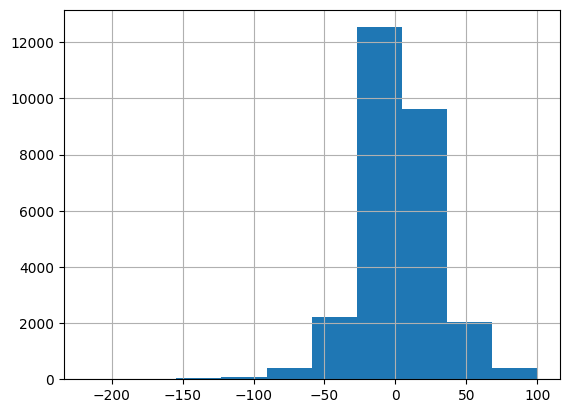

In [24]:

greater_100 = merged_rent['Difference'] > 100
merged_rent[~greater_100]['Difference'].hist()

### Scatter Plot Comparing Interpolated and Given Median Values

Text(0, 0.5, 'Mediant Estimates from ACS')

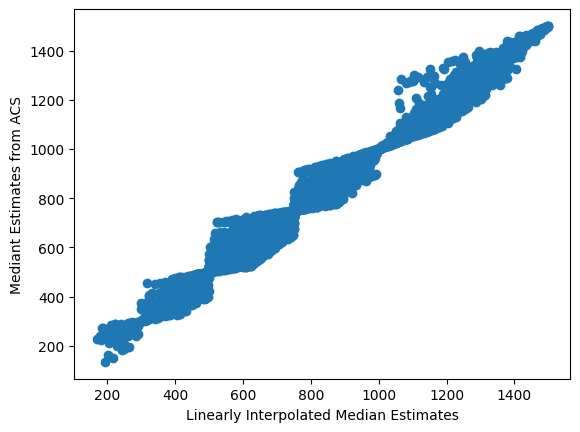

In [25]:
plt.scatter(merged_rent[~greater_100]['Median'],merged_rent[~greater_100]['B25031_004E'])
plt.xlabel("Linearly Interpolated Median Estimates")
plt.ylabel("Mediant Estimates from ACS")

### Forming and Saving DataFrame

In [26]:
MEDIAN_RENT = "Median_Rent_02.csv"
median_rent = median_rent.rename(columns={'Median':'MedianRent'})
median_rent.to_csv(MEDIAN_RENT,index=False)

# `Median Income`

## Checking Validity of Variable

In [27]:
#B19013_001E
# looking at metadata for this variable for
# the first year it's present
variable_mask = metadata['Variable'] == 'B19013_001E'
metadata[variable_mask].iloc[0]


Variable                                          B19013_001E
Label       Estimate!!Median household income in the past ...
Concept     MEDIAN HOUSEHOLD INCOME IN THE PAST 12 MONTHS ...
Year                                                     2009
Name: 8328, dtype: object

In [28]:
missing_years = find_all_missing_years(metadata,['B19013_001E'])
if not missing_years:
    print("No missing years found")
else:
    print(missing_years)

No missing years found


## Summary of `Median Income`

This variable is located in all years. The concept matches the intended variable. This can be downloaded as is.
* Final Variable to Download:
    * B19013_001E

## Downloading Variable B19013_001E - MedianIncome

In [29]:
MEDIAN_INCOME = "Median_Income_03.csv"

target_variables = ["B19013_001E"]
target_years = list(range(2009,2024))

if download_necessary([MEDIAN_INCOME]):
    total_population_df = download_variables(target_variables,target_years)
    total_population_df.to_csv(MEDIAN_INCOME, index=False)
else:
    base_dict = {
        'GEOID' : str,
        'Year' : int,
        'State' : str,
        'County' : str,
    }
    data_types = base_dict.copy()
    data_types['MedianIncome'] = float

    median_income_df = pd.read_csv(MEDIAN_INCOME,dtype=data_types)
    # str int str str float

# `Poverty Rate`

## Checking Validity of Variable

In [30]:
#B17001_001E
# looking at metadata for this variable for
# the first year it's present
variable_mask = metadata['Variable'] == 'B17001_001E'
metadata[variable_mask].iloc[0]

Variable                                          B17001_001E
Label                                         Estimate!!Total
Concept     POVERTY STATUS IN THE PAST 12 MONTHS BY SEX BY...
Year                                                     2009
Name: 4688, dtype: object

In [31]:
missing_years = find_all_missing_years(metadata, ['B17001_001E'])
if not missing_years:
    print("No missing years found")
else:
    print(missing_years)

No missing years found


In [32]:
#B17001_002E
# looking at metadata for this variable for
# the first year it's present
variable_mask = metadata['Variable'] == 'B17001_002E'
metadata[variable_mask].iloc[0]

Variable                                          B17001_002E
Label       Estimate!!Total!!Income in the past 12 months ...
Concept     POVERTY STATUS IN THE PAST 12 MONTHS BY SEX BY...
Year                                                     2009
Name: 4698, dtype: object

In [33]:
missing_years = find_all_missing_years(metadata, ['B17001_002E'])
if not missing_years:
    print("No missing years found")
else:
    print(missing_years)

No missing years found


## Summary of `Poverty Rate`

The variables are located in all years. The variable B17001_001E is the total population for which poverty status was determined. The variable B17001_002E is the total population count of those below the poverty level.

* Final Variables to Download:
    * B17001_001E
    * B17001_002E
* Formula for Poverty Rate:
    * B17001_002E / B17001_001E

## Downloading Variables B17001_XXXE - PovertyRate

In [34]:
POVERTY_RATE = "Poverty_Rate_04.csv"

target_variables = ["B17001_001E", "B17001_002E"]
target_years = list(range(2009,2024))

if download_necessary([POVERTY_RATE]):
    poverty_rate_df = download_variables(target_variables,target_years)
    poverty_rate_df["PovertyRate"] = poverty_rate_df['B17001_002E'] / poverty_rate_df['B17001_001E']
    poverty_rate_df["PovertyNumerator"] = poverty_rate_df['B17001_002E']
    poverty_rate_df["PovertyDenominator"] = poverty_rate_df['B17001_001E']
    poverty_rate_df.to_csv(POVERTY_RATE, index=False)
else:
    base_dict = {
        'GEOID' : str,
        'Year' : int,
        'State' : str,
        'County' : str,
    }
    data_types = base_dict.copy()

    poverty_rate_df = pd.read_csv(POVERTY_RATE,dtype=data_types)

In [35]:
poverty_rate_df

,GEOID,Year,State,County,B17001_001E,B17001_002E,PovertyRate,PovertyNumerator,PovertyDenominator
0,13091,2009,13,091,17048.0,3805.0,0.223193,3805.0,17048.0
1,13093,2009,13,093,9292.0,2553.0,0.274752,2553.0,9292.0
2,13095,2009,13,095,92286.0,23294.0,0.252411,23294.0,92286.0
3,13097,2009,13,097,121543.0,13260.0,0.109097,13260.0,121543.0
4,13099,2009,13,099,11536.0,3111.0,0.269678,3111.0,11536.0
...,...,...,...,...,...,...,...,...,...
48306,72145,2023,72,145,53745.0,22724.0,0.422811,22724.0,53745.0
48307,72147,2023,72,147,8147.0,4850.0,0.595311,4850.0,8147.0
48308,72149,2023,72,149,21670.0,9065.0,0.418320,9065.0,21670.0
48309,72151,2023,72,151,29821.0,14826.0,0.497166,14826.0,29821.0


# `Vacancy Rate`

## Checking Validity of Variables

In [36]:
#B25004_002E
# looking at metadata for this variable for
# the first year it's present
variable_mask = metadata['Variable'] == 'B25004_002E'
metadata[variable_mask].iloc[0]

Variable                  B25004_002E
Label       Estimate!!Total!!For rent
Concept                VACANCY STATUS
Year                             2009
Name: 5594, dtype: object

In [37]:
concept_mask = metadata['Concept'] == 'VACANCY STATUS'
year_mask = 2009
metadata[concept_mask&year_mask]

,Variable,Label,Concept,Year
5571,B25004_005E,"Estimate!!Total!!Sold, not occupied",VACANCY STATUS,2009
5573,B25004_006E,"Estimate!!Total!!For seasonal, recreational, o...",VACANCY STATUS,2009
5576,B25004_004E,Estimate!!Total!!For sale only,VACANCY STATUS,2009
5585,B25004_003E,"Estimate!!Total!!Rented, not occupied",VACANCY STATUS,2009
5594,B25004_002E,Estimate!!Total!!For rent,VACANCY STATUS,2009
...,...,...,...,...
9691,B25004_003E,"Estimate!!Total:!!Rented, not occupied",VACANCY STATUS,2021
9699,B25004_002E,Estimate!!Total:!!For rent,VACANCY STATUS,2021
9705,B25004_001E,Estimate!!Total:,VACANCY STATUS,2021
9733,B25004_008E,Estimate!!Total:!!Other vacant,VACANCY STATUS,2021


In [38]:

missing_years = find_all_missing_years(metadata, ['B25004_002E'])
if not missing_years:
    print("No missing years found")
else:
    print(missing_years)

No missing years found


In [39]:
#B25003_003E
# looking at metadata for this variable for
# the first year it's present
variable_mask = metadata['Variable'] == 'B25003_003E'
metadata[variable_mask].iloc[0]

Variable                         B25003_003E
Label       Estimate!!Total!!Renter occupied
Concept                               TENURE
Year                                    2009
Name: 6455, dtype: object

In [40]:

missing_years = find_all_missing_years(metadata, ['B25003_003E'])
if not missing_years:
    print("No missing years found")
else:
    print(missing_years)

No missing years found


## Summary of Vacancy Rate

The variables are located in all years. The vacancy rate is the Vacant_Rentals / All_Rentals. B25004_002E is rentals that are vacant. B25003_003E is the count of Occupied Rentals. Total Rentals are vacant + occupied.

* Final Variable to Download:
    * B25004_002E
    * B25003_003E
* Formula for Vacancy Rate
    * B25004_002E / (B25004_002E + B25004_003E)

## Downloading Variables B25004_002E B25003_003E - VacancyRate

In [41]:
VACANCY_RATE = "Vacancy_Rate_05.csv"

target_variables = ["B25004_002E", "B25003_003E"]
target_years = list(range(2009,2024))

if download_necessary([VACANCY_RATE]):
    vacancy_rate_df = download_variables(target_variables,target_years)
    vacancy_rate_df["VacancyRate"] = vacancy_rate_df['B25004_002E'] / (vacancy_rate_df['B25004_002E'] + vacancy_rate_df['B25003_003E'])
    vacancy_rate_df["VacancyNumerator"] = vacancy_rate_df['B25004_002E']
    vacancy_rate_df["VacancyDenominator"] = (vacancy_rate_df['B25004_002E'] + vacancy_rate_df['B25003_003E'])
    vacancy_rate_df.to_csv(VACANCY_RATE, index=False)
else:
    base_dict = {
        'GEOID' : str,
        'Year' : int,
        'State' : str,
        'County' : str,
    }
    data_types = base_dict.copy()
    data_types['VacancyRate'] = float

    poverty_rate_df = pd.read_csv(POVERTY_RATE,dtype=data_types)

# `Renter Occupied Rate`

## Checking Validity of Variable

In [42]:
#B25003_001E
# looking at metadata for this variable for
# the first year it's present
variable_mask = metadata['Variable'] == 'B25003_001E'
metadata[variable_mask].iloc[0]

Variable        B25003_001E
Label       Estimate!!Total
Concept              TENURE
Year                   2009
Name: 6691, dtype: object

In [43]:
#B25003_003E
# looking at metadata for this variable for
# the first year it's present
variable_mask = metadata['Variable'] == 'B25003_003E'
metadata[variable_mask].iloc[0]

Variable                         B25003_003E
Label       Estimate!!Total!!Renter occupied
Concept                               TENURE
Year                                    2009
Name: 6455, dtype: object

## Summary of Renter Occupied Rate

The variables are located in all years. The renter occupied rate is the Renter_Occupied / Total Occupied. B25003_003E is rentals that are occupied. B25003_001E is the count of all Occupancy Locations.

* Final Variable to Download:
    * B25003_003E
    * B25003_001E
* Formula for Occupied Rate
    * B25003_003E / B25003_001E

## Downloading Variables B25003_003E B25003_001E - RenterOccupiedRate

In [44]:
RENTER_OCCUPIED_RATE = "Renter_Occupied_Rate_06.csv"

target_variables = ["B25003_003E", "B25003_001E"]
target_years = list(range(2009,2024))

if download_necessary([RENTER_OCCUPIED_RATE]):
    occupied_rate_df = download_variables(target_variables,target_years)
    occupied_rate_df["RenterOccupiedRate"] = occupied_rate_df['B25003_003E'] / occupied_rate_df['B25003_001E']
    occupied_rate_df["RenterOccupiedNumerator"] = occupied_rate_df['B25003_003E']
    occupied_rate_df["RenterOccupiedDenominator"] = occupied_rate_df['B25003_001E']
    occupied_rate_df.to_csv(RENTER_OCCUPIED_RATE, index=False)
else:
    base_dict = {
        'GEOID' : str,
        'Year' : int,
        'State' : str,
        'County' : str,
    }
    data_types = base_dict.copy()
    data_types['RenterOccupiedRate'] = float

    poverty_rate_df = pd.read_csv(POVERTY_RATE,dtype=data_types)

# `Rent Burdened Rate`

## Checking Variable Concepts

In [45]:
var_mask = metadata["Variable"] == "B25106_018E"
df_temp = metadata.loc[var_mask, ["Year","Label", "Concept"]]
df_temp.iloc[0]

Year                                                    2010
Label      Estimate!!Total!!Owner-occupied housing units!...
Concept    TENURE BY HOUSING COSTS AS A PERCENTAGE OF HOU...
Name: 2191, dtype: object

## Variable Explanation
This variable, B25106_018E, estimates the total households whose occupants make a total income between 50k and 75k and also spend 30 percent or more on Housing costs. Of note, this variable is **owner-occupied** not renter-occupied. The documentation from BU Project said the variables tracked renters. So there is a discrepancy that needs to be addressed. I list all variables with the same concept as B25106_018E to determine the solution to this discrepancy.

In [46]:
concept_mask = metadata["Concept"] == "TENURE BY HOUSING COSTS AS A PERCENTAGE OF HOUSEHOLD INCOME IN THE PAST 12 MONTHS"
year_mask = metadata["Year"] == 2010
metadata.loc[concept_mask & year_mask, ["Variable", "Label"]]

,Variable,Label
1301,B25106_046E,Estimate!!Total!!Renter-occupied housing units...
1306,B25106_045E,Estimate!!Total!!Renter-occupied housing units...
1459,B25106_040E,Estimate!!Total!!Renter-occupied housing units...
1470,B25106_042E,Estimate!!Total!!Renter-occupied housing units...
1477,B25106_041E,Estimate!!Total!!Renter-occupied housing units...
1484,B25106_044E,Estimate!!Total!!Renter-occupied housing units...
1492,B25106_043E,Estimate!!Total!!Renter-occupied housing units...
1658,B25106_022E,Estimate!!Total!!Owner-occupied housing units!...
1662,B25106_021E,Estimate!!Total!!Owner-occupied housing units!...
1665,B25106_025E,Estimate!!Total!!Renter-occupied housing units...


## Clarifying Documentation Error


*  The variables mentioned in the [readme](https://github.com/BU-Spark/ds-ciss-predictive-homlessness/blob/76d8be480f6b32075f4193776988ed61aac92687/README_dataset.md#L31) incorrectly listed for the cost burdened rate are listed below. These variables all have **owner--occupied** by them :
   *  B25106_006E
   *  B25106_010E
   *  B25106_014E
   *  B25106_018E
*  The variables actually downloaded from the [.Rmd file](https://github.com/BU-Spark/ds-ciss-predictive-homlessness/blob/76d8be480f6b32075f4193776988ed61aac92687/Final%20Code%201.Rmd#L119) listed below, are stated in the metadata as renter occupied. Therefore, the list in the Readme must be an error in the documentation. The below variables are the ones we need to download.
   *  B25106_028E
   *  B25106_032E
   *  B25106_036E
   *  B25106_040E
   *  B25106_044E

In [47]:

correct_variables_of_interest = ["B25106_028E", "B25106_032E", "B25106_036E", "B25106_040E", "B25106_044E"]
correct_vars_missing = find_all_missing_years(metadata,correct_variables_of_interest)
print(correct_vars_missing)

{'B25106_028E': [2009], 'B25106_032E': [2009], 'B25106_036E': [2009], 'B25106_040E': [2009], 'B25106_044E': [2009]}


## Data Availability:

*  Introduction: These variables were first introduced in the 2015 American Community Survey (ACS).
* Back-filling: They were retroactively added to the datasets for the years 2010 through 2014.
* 2009 Data Gap: Consequently, the variables are entirely missing from the 2009 dataset.
* Workaround: For 2009, an equivalent total is calculated by summing the following variables
    *  B25070_007E
    *  B25070_008E
    *  B25070_009E
    *  B25070_010E


For the years 2010 through 2015 the sum of our variables from B25106 should equate to the sum from B25070. I will confirm this theory before moving forwards.

## Checking Years Present for Workaround Variables

The workaround variables are present in all years of the data, as listed below.

In [48]:
variables_to_target = ["B25070_008E", "B25070_009E", "B25070_010E", "B25070_007E"]
print(find_all_missing_years(metadata,variables_to_target))

{}


## Checking Labels for Workaround Variables

In [49]:
var_mask = metadata['Variable'].isin(variables_to_target)
year_mask = metadata['Year'] == 2010
metadata.loc[var_mask & year_mask, ["Variable", "Label","Concept"]]

,Variable,Label,Concept
8540,B25070_007E,Estimate!!Total!!30.0 to 34.9 percent,GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME...
8585,B25070_009E,Estimate!!Total!!40.0 to 49.9 percent,GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME...
8593,B25070_008E,Estimate!!Total!!35.0 to 39.9 percent,GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME...
8678,B25070_010E,Estimate!!Total!!50.0 percent or more,GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME...


In [50]:
var_mask = metadata['Variable'].isin(correct_variables_of_interest)
year_mask = metadata['Year'] == 2010
metadata.loc[var_mask & year_mask, ["Variable", "Label", "Concept"]]

,Variable,Label,Concept
1459,B25106_040E,Estimate!!Total!!Renter-occupied housing units...,TENURE BY HOUSING COSTS AS A PERCENTAGE OF HOU...
1484,B25106_044E,Estimate!!Total!!Renter-occupied housing units...,TENURE BY HOUSING COSTS AS A PERCENTAGE OF HOU...
1699,B25106_028E,Estimate!!Total!!Renter-occupied housing units...,TENURE BY HOUSING COSTS AS A PERCENTAGE OF HOU...
1829,B25106_036E,Estimate!!Total!!Renter-occupied housing units...,TENURE BY HOUSING COSTS AS A PERCENTAGE OF HOU...
1968,B25106_032E,Estimate!!Total!!Renter-occupied housing units...,TENURE BY HOUSING COSTS AS A PERCENTAGE OF HOU...


Reading the labels for both sets of variables implies that summing our target variables from both tables will yield the renters who spend 30 percent or more on rent. These two sums should equate with each other. And the first sum is available in all years. We check this working theory below.

## Downloading and Save Variable Data

In [51]:
RENT_BURDENED_FILE_PREFIX = 'rent_burdened_'
RENTERS_FILE_1 = f"{RENT_BURDENED_FILE_PREFIX}_B25070.csv"
RENTERS_FILE_2 = f"{RENT_BURDENED_FILE_PREFIX}_B25106.csv"

if download_necessary([RENTERS_FILE_1,RENTERS_FILE_2]):
    # Variables from ACS to download
    # present in all years
    set1_to_download = [ "B25070_007E", "B25070_009E", "B25070_008E", "B25070_010E"]
    # missing in 2009
    set2_to_download = [ "B25106_028E", "B25106_032E", "B25106_036E", "B25106_040E", "B25106_044E"]

    # Years to Download For
    set1_years = list(range(2009,2024))
    set2_years = list(range(2010,2024))

    # get the data from the server
    print("Download set one. . .")
    B25070 = download_variables(set1_to_download, set1_years)
    print("Download set two. . .")
    B25106 = download_variables(set2_to_download, set2_years)

    # save to disk
    B25070.to_csv(RENTERS_FILE_1, index=False)
    B25106.to_csv(RENTERS_FILE_2, index=False)

else:
    B25070 = pd.read_csv(RENTERS_FILE_1,dtype=base_dict)
    B25106 = pd.read_csv(RENTERS_FILE_2,dtype=base_dict)




Download set one. . .


Download set two. . .


In [52]:
denominator = [ 'B25003_003E' ]
all_years = list(range(2009,2024))
denom_df = download_variables(denominator,all_years)

## Compute Totals and Differences

In [53]:
B25070["Year"].unique()

# summing the variables
B25070["B25070_Total"] = B25070["B25070_007E"] + B25070["B25070_008E"] + B25070["B25070_009E"] + B25070["B25070_010E"]
B25106["B25106_Total"] = B25106["B25106_028E"] + B25106["B25106_032E"] + B25106["B25106_036E"] + B25106["B25106_040E"] + B25106["B25106_044E"]
var_comparisons = pd.merge(left=B25106, right=B25070, on=["Year", "GEOID"], how="left")

# Finding the differences of the vars
var_comparisons['Difference'] = var_comparisons['B25106_Total'] - var_comparisons['B25070_Total']

# count number of differences other than zero
diff_mask = var_comparisons["Difference"] == 0
print(f"{sum(diff_mask)} out of {len(var_comparisons)} GEOID's match")

45052 out of 45090 GEOID's match


In [54]:
var_comparisons[~diff_mask]['Difference']

31       -7.0
491     -11.0
2141    -44.0
2153     -7.0
2244    -13.0
2810    -31.0
2983     -8.0
3731    -45.0
3740     -7.0
4402    -15.0
4647    -18.0
4932     -9.0
5059    -31.0
5579     -6.0
6626    -15.0
7323     -7.0
9330    -30.0
18670   -11.0
18807    -7.0
18973    -8.0
19672    -6.0
19955    -8.0
20273   -10.0
23254    -6.0
24494    -9.0
25684    -8.0
26818     NaN
26952    -8.0
27594    -9.0
27759    -7.0
28431    -8.0
29817    -9.0
29845    -8.0
30864    -9.0
30933    -9.0
33493   -25.0
37277   -34.0
40499   -19.0
Name: Difference, dtype: float64

The differences are few and small in magnitude. It appears the two sums do equate.

## Save ACS Table Data

In [56]:
RENT_BURDENED_RATE = "Rent_Burdened_Rate_07.csv"

if os.path.exists(RENT_BURDENED_RATE):
    base_dict = {
        'GEOID' : str,
        'Year' : int,
        'State' : str,
        'County' : str,
    }
    data_types = base_dict.copy()
    data_types['RentBurdenedRate'] = float

    print("Reading file.")
    rent_burdened_rate_df = pd.read_csv(RENT_BURDENED_RATE,dtype=data_types)
else:
    print("Creating and Saving File.")
    B25070 = B25070.rename(columns={"B25070_Total": "RentBurdenedCount",})

    rent_burdened_rate_df = B25070[["GEOID","Year","State","County","RentBurdenedCount"]]

    rent_burdened_rate_df = pd.merge(left=rent_burdened_rate_df,right=denom_df,how='outer',on=["GEOID","Year","State","County"])

    rent_burdened_rate_df["RentBurdenedRate"] = rent_burdened_rate_df["RentBurdenedCount"] / rent_burdened_rate_df["B25003_003E"]
    rent_burdened_rate_df["RentBurdenedNumerator"] = rent_burdened_rate_df["RentBurdenedCount"]
    rent_burdened_rate_df["RentBurdenedDenominator"] = rent_burdened_rate_df["B25003_003E"]

    rent_burdened_rate_df = rent_burdened_rate_df[["GEOID","Year","State","County","RentBurdenedRate","RentBurdenedNumerator","RentBurdenedDenominator"]]

    rent_burdened_rate_df.to_csv(RENT_BURDENED_RATE, index=False)

Creating and Saving File.


# 'Unemployment Rate'

## Checking Validity of Variable

In [57]:
# B23025_003E
# looking at metadata for this variable for
# the first year it's present
variable_mask = metadata['Variable'] == 'B23025_003E'
metadata[variable_mask].iloc[0]

Variable                                          B23025_003E
Label       Estimate!!Total!!In labor force!!Civilian labo...
Concept     EMPLOYMENT STATUS FOR THE POPULATION 16 YEARS ...
Year                                                     2011
Name: 7848, dtype: object

In [58]:
# B23025_005E
# looking at metadata for this variable for
# the first year it's present
variable_mask = metadata['Variable'] == 'B23025_005E'
metadata[variable_mask].iloc[0]

Variable                                          B23025_005E
Label       Estimate!!Total!!In labor force!!Civilian labo...
Concept     EMPLOYMENT STATUS FOR THE POPULATION 16 YEARS ...
Year                                                     2011
Name: 7846, dtype: object

In [59]:
find_all_missing_years(metadata, ['B23025_003E','B23025_005E'])

{'B23025_003E': [2009, 2010], 'B23025_005E': [2009, 2010]}

## Summary of Total Population
This variable is missing from 2009 and 2010. But can be downloaded from other variables in the ACS table B23001. The variables to download for the unemployment total is:
* List unemployment variables

The variables to download for the total number of people in the labor force is:
* B23001_006E: Male: 16 to 19 years: In labor force: Civilian
* B23001_013E: Male: 20 and 21 years: In labor force: Civilian
* B23001_020E: Male: 22 to 24 years: In labor force: Civilian
* B23001_027E: Male: 25 to 29 years: In labor force: Civilian
* B23001_034E: Male: 30 to 34 years: In labor force: Civilian
* B23001_041E: Male: 35 to 44 years: In labor force: Civilian
* B23001_048E: Male: 45 to 54 years: In labor force: Civilian
* B23001_055E: Male: 55 to 59 years: In labor force: Civilian
* B23001_062E: Male: 60 and 61 years: In labor force: Civilian
* B23001_069E: Male: 62 to 64 years: In labor force: Civilian
* B23001_076E: Male: 65 to 69 years: In labor force
* B23001_081E: Male: 70 to 74 years: In labor force
* B23001_086E: Male: 75 years and over: In labor force
* B23001_093E: Female: 16 to 19 years: In labor force: Civilian
* B23001_100E: Female: 20 and 21 years: In labor force: Civilian
* B23001_107E: Female: 22 to 24 years: In labor force: Civilian
* B23001_114E: Female: 25 to 29 years: In labor force: Civilian
* B23001_121E: Female: 30 to 34 years: In labor force: Civilian
* B23001_128E: Female: 35 to 44 years: In labor force: Civilian
* B23001_135E: Female: 45 to 54 years: In labor force: Civilian
* B23001_142E: Female: 55 to 59 years: In labor force: Civilian
* B23001_149E: Female: 60 and 61 years: In labor force: Civilian
* B23001_156E: Female: 62 to 64 years: In labor force: Civilian
* B23001_163E: Female: 65 to 69 years: In labor force
* B23001_168E: Female: 70 to 74 years: In labor force
* B23001_173E: Female: 75 years and over: In labor force

Summing these two lists and dividing them will supply the unemployment rate for 2009 and 2010.

## Downloading Variable B23001 - UnemploymentRate

In [60]:
UNEMPLOYMENT_RATE_A = "Unemployment_Rate_08_a.csv"
RAW_UNEMPLOYMENT_FILE_1 = 'raw_unemployment.csv'
RAW_UNEMPLOYMENT_FILE_2 = 'raw_labor_force.csv'

unemployment_variables = ['B23001_008E','B23001_015E','B23001_022E','B23001_029E','B23001_036E','B23001_043E',
                          'B23001_050E','B23001_057E','B23001_064E','B23001_071E','B23001_076E','B23001_081E',
                          'B23001_086E','B23001_094E','B23001_101E','B23001_108E','B23001_115E','B23001_122E',
                          'B23001_129E','B23001_136E','B23001_143E','B23001_150E','B23001_157E','B23001_162E',
                          'B23001_167E','B23001_172E']

labor_force_variables = ['B23001_092E','B23001_099E','B23001_106E','B23001_113E','B23001_120E','B23001_127E',
                             'B23001_134E','B23001_141E','B23001_148E','B23001_155E','B23001_160E','B23001_165E',
                             'B23001_170E','B23001_006E','B23001_013E','B23001_020E','B23001_027E','B23001_034E',
                             'B23001_041E','B23001_048E','B23001_055E','B23001_062E','B23001_069E','B23001_074E',
                             'B23001_079E','B23001_084E' ]
target_years = list(range(2009,2022))


if download_necessary([RAW_UNEMPLOYMENT_FILE_1,RAW_UNEMPLOYMENT_FILE_2]):
    unemployment_df = download_variables(unemployment_variables,target_years)
    labor_force_df = download_variables(labor_force_variables,target_years)

    columns_to_exclude = ['GEOID', 'Year', 'State', 'County']
    temp_view = unemployment_df.drop(columns=columns_to_exclude)
    unemployment_df["Unemployed_Total"] = temp_view.sum(axis=1)

    temp_view = labor_force_df.drop(columns=columns_to_exclude)
    labor_force_df["Labor_Force_Total"] = temp_view.sum(axis=1)

    unemployment_df.to_csv(RAW_UNEMPLOYMENT_FILE_1, index=False )
    labor_force_df.to_csv(RAW_UNEMPLOYMENT_FILE_2, index=False )

    labor_right = labor_force_df[["GEOID","Year","Labor_Force_Total"]]
    unemployment_rate_df = pd.merge(left=unemployment_df,right=labor_right,on=["GEOID","Year"])
    unemployment_rate_df = unemployment_rate_df[["GEOID","Year","State","County","Unemployed_Total", "Labor_Force_Total"]]
    unemployment_rate_df.to_csv(UNEMPLOYMENT_RATE_A,index=False)
else:
    data_types = base_dict.copy()
    unemployment_df = pd.read_csv(RAW_UNEMPLOYMENT_FILE_1,dtype=data_types)
    labor_force_df = pd.read_csv(RAW_UNEMPLOYMENT_FILE_2,dtype=data_types)
    unemployment_rate_df = pd.read_csv(UNEMPLOYMENT_RATE_A,dtype=data_types)

## Downloading Comparison Years

In [61]:
# B23025_003E, B23025_005E
UNEMPLOYMENT_RATE_B = "Unemployment_Rate_08_b.csv"
target_variables = ["B23025_003E", "B23025_005E"]
target_years = list(range(2011,2024))

if download_necessary([UNEMPLOYMENT_RATE_B]):
    unemployed_vars_2 = download_variables(target_variables,target_years)
    unemployed_vars_2.to_csv(UNEMPLOYMENT_RATE_B,index=False)

else:
    data_types = base_dict.copy()
    unemployed_vars_2 = pd.read_csv(UNEMPLOYMENT_RATE_B,dtype=data_types)


In [62]:
comparisons = pd.merge(left=unemployment_rate_df,right=unemployed_vars_2,on=["GEOID","Year"])

In [63]:
comparisons["Differences"] = comparisons["B23025_003E"] - comparisons['Labor_Force_Total']
diff_mask = comparisons['Differences'] == 0
print(sum(diff_mask))
comparisons[diff_mask]

35424


,GEOID,Year,State_x,County_x,Unemployed_Total,Labor_Force_Total,State_y,County_y,B23025_003E,B23025_005E,Differences
0,56037,2011,56,037,1264.0,23634.0,56,037,23634.0,1264.0,0.0
1,56031,2011,56,031,102.0,4273.0,56,031,4273.0,102.0,0.0
2,56033,2011,56,033,517.0,15481.0,56,033,15481.0,517.0,0.0
3,56003,2011,56,003,303.0,5662.0,56,003,5662.0,303.0,0.0
4,56011,2011,56,011,64.0,3511.0,56,011,3511.0,64.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
35420,72145,2021,72,145,3482.0,19789.0,72,145,19789.0,3482.0,0.0
35421,72147,2021,72,147,358.0,2355.0,72,147,2355.0,358.0,0.0
35422,72149,2021,72,149,1464.0,7856.0,72,149,7856.0,1464.0,0.0
35423,72151,2021,72,151,1506.0,9897.0,72,151,9897.0,1506.0,0.0


## Combining Numbers from Different Methods

In [66]:
unemployed_vars_2['UnemploymentRate'] = unemployed_vars_2['B23025_005E'] / unemployed_vars_2['B23025_003E']
unemployed_vars_2['UnemploymentNumerator'] = unemployed_vars_2['B23025_005E']
unemployed_vars_2['UnemploymentDenominator'] = unemployed_vars_2['B23025_003E']
unemployment_rate_df['UnemploymentRate'] = unemployment_rate_df['Unemployed_Total'] / unemployment_rate_df['Labor_Force_Total']
unemployment_rate_df['UnemploymentNumerator'] = unemployment_rate_df['Unemployed_Total']
unemployment_rate_df['UnemploymentDenominator'] = unemployment_rate_df['Labor_Force_Total']

df_1 = unemployment_rate_df[['GEOID','Year','State','County', 'UnemploymentRate', 'UnemploymentNumerator', 'UnemploymentDenominator']].copy()

filter = unemployed_vars_2['Year'] >= 2022
df_2 = unemployed_vars_2[filter][['GEOID','Year','State','County', 'UnemploymentRate','UnemploymentNumerator', 'UnemploymentDenominator']].copy()

complete_df = pd.concat([df_1,df_2])
UNEMPLOYMENT_RATE = 'Unemployment_Rate_08.csv'
complete_df.to_csv(UNEMPLOYMENT_RATE,index=False)

# Creating Final DataFrame

In [68]:
# TOTAL_POPULATION
# MEDIAN_RENT
# MEDIAN_INCOME
# POVERTY_RATE
# VACANCY_RATE
# RENTER_OCCUPIED_RATE
# RENT_BURDENED_RATE
# UNEMPLOYMENT_RATE
base_dict = {
        'GEOID' : str,
        'Year' : int,
        'State' : str,
        'County' : str,
    }
df_1 = pd.read_csv(TOTAL_POPULATION,dtype=base_dict)
df_2 = pd.read_csv(MEDIAN_RENT,dtype=base_dict)
df_3 = pd.read_csv(MEDIAN_INCOME,dtype=base_dict)
df_4 = pd.read_csv(POVERTY_RATE,dtype=base_dict)
df_5 = pd.read_csv(VACANCY_RATE,dtype=base_dict)
df_6 = pd.read_csv(RENTER_OCCUPIED_RATE,dtype=base_dict)
df_7 = pd.read_csv(RENT_BURDENED_RATE,dtype=base_dict)
df_8 = pd.read_csv(UNEMPLOYMENT_RATE,dtype=base_dict)

# merge all dataframes
dataframes_to_merge = [ df_1, df_2, df_3, df_4, df_5, df_6, df_7, df_8 ]
join_keys = ["GEOID", "Year", "County", "State"]
final_ACS_df = dataframes_to_merge[0]

# loop through each dataframe from 1 on
# use outer so all rows are preserved
for i,df_to_merge in enumerate(dataframes_to_merge[1:]):
     final_ACS_df = pd.merge(
         final_ACS_df,
         df_to_merge,
         on=join_keys,
         how='outer'
     )

print(final_ACS_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48311 entries, 0 to 48310
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   GEOID                      48311 non-null  object 
 1   Year                       48311 non-null  int32  
 2   State                      48311 non-null  object 
 3   County                     48311 non-null  object 
 4   B01003_001E                48311 non-null  float64
 5   MedianRent                 46583 non-null  float64
 6   B19013_001E                48309 non-null  float64
 7   B17001_001E                48310 non-null  float64
 8   B17001_002E                48310 non-null  float64
 9   PovertyRate                48310 non-null  float64
 10  PovertyNumerator           48310 non-null  float64
 11  PovertyDenominator         48310 non-null  float64
 12  B25004_002E                48311 non-null  float64
 13  B25003_003E_x              48311 non-null  flo

In [73]:
final_ACS_df = final_ACS_df.rename(columns={"B01003_001E":"TotalPopulation","B19013_001E":"MedianIncome"})
# final_ACS_df[["GEOID","TotalPopulation","MedianRent","MedianIncome","PovertyRate","VacancyRate","RenterOccupiedRate","RentBurdenedRate","UnemploymentRate"]]
ACS_data = final_ACS_df[['GEOID', 'Year', 'State', 'County', 'TotalPopulation', 'MedianRent',
       'MedianIncome', 'PovertyRate',
       'PovertyNumerator', 'PovertyDenominator', 'VacancyRate', 'VacancyNumerator',
       'VacancyDenominator', 'RenterOccupiedRate', 'RenterOccupiedNumerator',
       'RenterOccupiedDenominator', 'RentBurdenedRate',
       'RentBurdenedNumerator', 'RentBurdenedDenominator', 'UnemploymentRate',
       'UnemploymentNumerator', 'UnemploymentDenominator']]
ACS_data

,GEOID,Year,State,County,TotalPopulation,MedianRent,MedianIncome,PovertyRate,PovertyNumerator,PovertyDenominator,...,VacancyDenominator,RenterOccupiedRate,RenterOccupiedNumerator,RenterOccupiedDenominator,RentBurdenedRate,RentBurdenedNumerator,RentBurdenedDenominator,UnemploymentRate,UnemploymentNumerator,UnemploymentDenominator
0,13091,2009,13,091,19695.0,441.345794,31334.0,0.223193,3805.0,17048.0,...,2365.0,0.302191,2096.0,6936.0,0.258588,542.0,2096.0,0.062580,442.0,7063.0
1,13093,2009,13,093,11641.0,447.167442,30172.0,0.274752,2553.0,9292.0,...,1378.0,0.339314,1286.0,3790.0,0.482893,621.0,1286.0,0.069630,271.0,3892.0
2,13095,2009,13,095,95330.0,576.910954,34597.0,0.252411,23294.0,92286.0,...,19881.0,0.505754,18589.0,36755.0,0.451073,8385.0,18589.0,0.122589,5339.0,43552.0
3,13097,2009,13,097,122657.0,851.066947,55512.0,0.109097,13260.0,121543.0,...,13968.0,0.293261,12441.0,42423.0,0.449883,5597.0,12441.0,0.096686,6199.0,64115.0
4,13099,2009,13,099,11812.0,345.409396,28063.0,0.269678,3111.0,11536.0,...,1562.0,0.311302,1380.0,4433.0,0.457246,631.0,1380.0,0.080719,355.0,4398.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48306,72145,2023,72,145,54058.0,575.841703,23877.0,0.422811,22724.0,53745.0,...,5553.0,0.246509,5049.0,20482.0,0.264607,1336.0,5049.0,0.134242,2660.0,19815.0
48307,72147,2023,72,147,8147.0,438.056250,17531.0,0.595311,4850.0,8147.0,...,1082.0,0.310552,827.0,2663.0,0.177751,147.0,827.0,0.085572,223.0,2606.0
48308,72149,2023,72,149,21778.0,465.833333,24882.0,0.418320,9065.0,21670.0,...,1655.0,0.213919,1623.0,7587.0,0.203943,331.0,1623.0,0.135114,1057.0,7823.0
48309,72151,2023,72,151,29868.0,429.811258,21279.0,0.497166,14826.0,29821.0,...,3490.0,0.292347,3438.0,11760.0,0.288540,992.0,3438.0,0.096726,913.0,9439.0


In [74]:
ACS_data.to_csv("ACS_data.csv",index=False)

# Summary of Variables

| Label                                                                              | BU Documented Variable                               | True ACS Variables                                                           |  Notes |
|------------------------------------------------------------------------------------|------------------------------------------------------|------------------------------------------------------------------------------|--------|
 Total population of the local area                                                 | B01003_001E                                          | B01003_001E                                                                  | Correctly Documented
 Median gross rent for a 2-bedroom apartment.                                       | B25031_004E                                          | B25068_022E, B25068_023E, B25068_024E, B25068_025E, B25068_026E, B25068_027E | These are grouped counts, the median is determined from linear interpolation.
 Median household income in the past 12 months.                                     | B19013_001E                                          | B19013_001E                                                                  | Correctly Documented
 Poverty rate, indicating the percentage of individuals living below the poverty line. | B17001_001E                                       | B17001_002E, B17001_001E                                                     | Poverty rate determined by dividing _002E (those living below poverty) by _001E (total of those whose poverty rate were determined)
 Percentage of rental properties that are vacant.                                   | B25004_001E                                          | B25004_002E, B25003_003E                                                     | Vacancy rate determiend by _002E (total vacanct for rent) by (_002E + 003E (Renter Occupied))
 Percentage of households that are renter-occupied.                                 | B25008_001E                                          | B25003_003E, B25003_001E                                                     | Renter rates determined by 003E (renter occupied) / 001E (total occupied)
 Percentage of renter households paying more than 30% of their income toward rent.  | "B25106_006E, B25106_010E, B25106_014E, B25106_018E" | B25106_028E, B25106_032E, B25106_036E, B25106_040E, B25106_044E              | Adding up the true ACS variables lends this statistic
 "Unemployment rate, showing the percentage of the labor force that is unemployed." | B23001_001E                                          | B23025_003E, B23025_005E                                                     | _005E (unemployed count) / _003E (total labor foce)
